# Optimized nucleation

## Parameters

In [ ]:
# 2D TFIM parameters.
coupling: float = 1.0
gamma: float = 2.5
ydim: int = 5
xdim: int = 5
seed_columns: int = 2 if xdim % 2 == 0 else 1

# Tensor algebra parameters.
max_bond: int = 100
cutoff: float = 1e-10
dmrg_max_bond: int = 200

# Optimized nucleation parameters.
num_sweeps: int = 2            # Number of optimization sweeps.
max_iterations: int = 32       # Max iterations for L-BFGS.
warm_start_times = (4.0, 8.0, 16.0)

## Setup

### Install packages

In [2]:
#pip install cirq-core scienceplots quimb qiskit git+https://github.com/qiskit-community/mps-to-circuit

### Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')
from scipy.optimize import minimize

import quimb as qu
import quimb.tensor as qtn

import qiskit
from mps_to_circuit import mps_to_circuit

### Constants

In [4]:
PAULI_Z, PAULI_X, IDENTITY = qu.pauli("Z"), qu.pauli("X"), qu.eye(2)
PLUS = np.array([1.0, 1.0]) / np.sqrt(2.0)

BOND_GROUP_NAMES = ("interior_horizontal", "interior_vertical",
                    "new_horizontal", "new_vertical")
PARAMETER_NAMES = BOND_GROUP_NAMES + ("transverse_field",)
PARAMETERS_PER_LAYER = len(PARAMETER_NAMES)

CNOTS_PER_EXPZZ: int = 2      # ExpZZ = CNOT RZ CNOT
CNOTS_PER_SU4: int = 3        # For a general two-qubit gate from mps_to_circuit.

### Lattice Hamiltonian

In [5]:
def window_columns(xdim, stage_columns):
    """The stage_columns columns centred in an xdim-column register."""
    first = (xdim - stage_columns) // 2
    return range(first, first + stage_columns)


def lattice_bonds(ydim, columns):
    """(a, b) site pairs over `columns`; site index = column * ydim + row."""
    columns = list(columns)
    site = lambda column, row: column * ydim + row
    horizontal = [(site(c, r), site(c + 1, r))
                  for c, next_c in zip(columns, columns[1:]) for r in range(ydim)]
    vertical = [(site(c, r), site(c, r + 1))
                for c in columns for r in range(ydim - 1)]
    return horizontal, vertical


def bond_groups(ydim, xdim, stage_columns):
    """Split a stage's bonds into interior/new x horizontal/vertical."""
    columns = list(window_columns(xdim, stage_columns))
    new_columns = {columns[0], columns[-1]}
    horizontal, vertical = lattice_bonds(ydim, columns)
    is_new = lambda bond: (bond[0] // ydim in new_columns
                           or bond[1] // ydim in new_columns)
    return {
        "interior_horizontal": [b for b in horizontal if not is_new(b)],
        "interior_vertical": [b for b in vertical if not is_new(b)],
        "new_horizontal": [b for b in horizontal if is_new(b)],
        "new_vertical": [b for b in vertical if is_new(b)],
    }

In [6]:
def tfim_mpo(ydim, xdim, columns=None):
    """MPO on ydim*xdim sites; bonds only within `columns`, field on every site."""
    num_sites = ydim * xdim
    horizontal, vertical = lattice_bonds(ydim, range(xdim) if columns is None else columns)

    def product_mpo(operators, scale):
        return scale * qtn.MPO_product_operator(
            [operators.get(s, IDENTITY) for s in range(num_sites)])

    terms = [product_mpo({a: PAULI_Z, b: PAULI_Z}, coupling)
             for a, b in horizontal + vertical]
    terms += [product_mpo({s: PAULI_X}, -gamma) for s in range(num_sites)]
    mpo = terms[0]
    for term in terms[1:]:
        mpo = mpo + term
    mpo.compress(cutoff=1e-12)
    return mpo


def dmrg_ground_state(mpo, max_bond=64, tol=1e-10):
    """Ground state energy and MPS."""
    dmrg = qtn.DMRG2(mpo, bond_dims=[min(16, max_bond), max_bond], cutoffs=1e-12)
    dmrg.solve(tol=tol, verbosity=0)
    return float(np.real(dmrg.energy)), dmrg.state

### Seed state

In [7]:
def seed_register_state(ydim, xdim, seed_columns, max_bond=64):
    """DMRG ground state of the seed columns, with |+> on every other site.

    Built by running DMRG on the full register with bonds restricted to the seed
    window: the inactive sites see only -gamma X, whose ground state is |+>.
    """
    mpo = tfim_mpo(ydim, xdim, columns=window_columns(xdim, seed_columns))
    energy, mps = dmrg_ground_state(mpo, max_bond)
    return energy, mps

### Gates and layers

In [8]:
def exp_zz(theta):
    return np.diag(np.exp(-1j * theta * np.array([1.0, -1.0, -1.0, 1.0])))


def exp_x(theta):
    return np.cos(theta) * np.eye(2) + 1j * np.sin(theta) * np.asarray(PAULI_X)


def apply_layer(mps, groups, angles, window_sites, max_bond, cutoff,
                contract="swap+split"):
    """One ansatz layer, out of place. Returns the new MPS.

    Long-range bonds are routed with swaps. "auto-split-gate" looks ~6x faster
    but leaves multiple tensors per site, i.e. no longer an MPS, so it is not a
    valid substitute here.
    """
    mps = mps.copy()
    for name in BOND_GROUP_NAMES:
        angle = angles[name]
        if angle == 0.0:
            continue
        gate = exp_zz(angle)
        for a, b in groups[name]:
            mps.gate_(gate, (a, b), contract=contract,
                      max_bond=max_bond, cutoff=cutoff)
    gate = exp_x(angles["transverse_field"])
    for s in window_sites:
        mps.gate_(gate, (s,), contract=True)
    return mps


def apply_layers(mps, groups, parameters, window_sites, max_bond, cutoff):
    for row in np.atleast_2d(parameters):
        mps = apply_layer(mps, groups, dict(zip(PARAMETER_NAMES, row)),
                          window_sites, max_bond, cutoff)
    return mps


def energy(mps, mpo):
    return float(np.real(qtn.expec_TN_1D(mps.H, mpo, mps) / (mps.H @ mps)))

In [9]:
def trotter_angles(num_layers, total_time):
    """Fixed Trotterized sin^2 ramp, in the five-angle layout."""
    step = total_time / num_layers
    rows = []
    for layer in range(num_layers):
        ramp = np.sin(0.5 * np.pi * (layer + 0.5) / num_layers) ** 2
        rows.append([coupling * step, coupling * step,
                     ramp * coupling * step, ramp * coupling * step, gamma * step])
    return np.array(rows)

## Optimized nucleation

In [10]:
ANGLE_BOUNDS = [(-np.pi, np.pi)] * PARAMETERS_PER_LAYER


def stage_columns_sequence(xdim, seed_columns):
    return range(seed_columns + 2, xdim + 1, 2)

def wrap_angles(parameters):
    """Wrap angles into [-pi, pi].

    Every angle here is 2*pi periodic -- ZZ and X both have eigenvalues +-1 -- so
    wrapping loses nothing, and it keeps a warm start inside ANGLE_BOUNDS instead
    of being clipped onto the boundary by the optimizer.
    """
    return (np.asarray(parameters, dtype=float) + np.pi) % (2 * np.pi) - np.pi


def pad_to_layers(parameters, num_layers):
    """Extend a converged parameter block to `num_layers` with identity layers.

    An all-zero row is exactly the identity, so a depth-(L+1) circuit warm started
    this way *begins* at the depth-L optimum rather than somewhere unrelated.
    """
    parameters = np.atleast_2d(np.asarray(parameters, dtype=float))
    missing = num_layers - len(parameters)
    if missing <= 0:
        return parameters[:num_layers].copy()
    return np.vstack([parameters, np.zeros((missing, PARAMETERS_PER_LAYER))])


def optimize_stage(mps, groups, sites, mpo, num_layers, warm_starts,
                   max_bond, cutoff, num_sweeps=2, max_iterations=15):
    """Layerwise optimization of one stage, with forward-state caching."""
    def build_cost(parameters, layer, num_active):
        prefix = apply_layers(mps, groups, parameters[:layer], sites, max_bond, cutoff)

        def cost(values):
            rows = np.vstack([values, parameters[layer + 1:num_active]]) \
                if num_active > layer + 1 else np.atleast_2d(values)
            state = apply_layers(prefix, groups, rows, sites, max_bond, cutoff)
            return energy(state, mpo)
        return cost

    best_parameters, best_energy = None, np.inf
    for start in warm_starts:
        parameters = wrap_angles(pad_to_layers(start, num_layers))
        for layer in range(num_layers):
            parameters[layer] = minimize(
                build_cost(parameters, layer, layer + 1), parameters[layer],
                method="L-BFGS-B", bounds=ANGLE_BOUNDS,
                options={"maxiter": max_iterations}).x
        for _ in range(num_sweeps):
            for layer in range(num_layers):
                parameters[layer] = minimize(
                    build_cost(parameters, layer, num_layers), parameters[layer],
                    method="L-BFGS-B", bounds=ANGLE_BOUNDS,
                    options={"maxiter": max_iterations}).x
        final = energy(apply_layers(mps, groups, parameters, sites, max_bond, cutoff), mpo)
        if final < best_energy:
            best_parameters, best_energy = parameters, final
    return best_parameters, best_energy


def run_optimized_nucleation(ydim, xdim, seed_columns, num_layers,
                             warm_start_times=(4.0, 8.0, 16.0),
                             max_bond=64, cutoff=1e-10,
                             num_sweeps=2, max_iterations=15,
                             nested_parameters=None, verbose=False):
    """Variational nucleation: same structure, angles optimized against energy.

    `nested_parameters` is the per-stage parameter list from a shallower run.
    Padded with identity layers it becomes this depth's primary warm start, so a
    deeper circuit starts from the shallower optimum instead of wandering into an
    unrelated basin. Trotter warm starts are kept on *every* stage as a fallback;
    trim `warm_start_times` to a single value if this is too slow.
    """
    _, mps = seed_register_state(ydim, xdim, seed_columns, max_bond)
    stage_parameters, num_gates = [], 0
    previous = None
    for index, stage in enumerate(stage_columns_sequence(xdim, seed_columns)):
        groups = bond_groups(ydim, xdim, stage)
        sites = [s for c in window_columns(xdim, stage) for s in
                 range(c * ydim, (c + 1) * ydim)]
        mpo = tfim_mpo(ydim, xdim, columns=window_columns(xdim, stage))

        starts = []
        if nested_parameters is not None and index < len(nested_parameters):
            starts.append(pad_to_layers(nested_parameters[index], num_layers))
        if previous is not None:
            starts.append(pad_to_layers(previous, num_layers))
        starts += [trotter_angles(num_layers, t) for t in warm_start_times]

        parameters, stage_energy = optimize_stage(
            mps, groups, sites, mpo, num_layers, starts,
            max_bond, cutoff, num_sweeps, max_iterations)
        previous = parameters
        stage_parameters.append(parameters)
        mps = apply_layers(mps, groups, parameters, sites, max_bond, cutoff)
        mps.normalize()
        num_gates += num_layers * sum(len(b) for b in groups.values())
        if verbose:
            print(f"  stage {stage}: energy = {stage_energy:+.6f}")
    return mps, stage_parameters, num_gates

## MPS to circuit

In [11]:
def apply_qiskit_circuit(qc, mps, max_bond, cutoff):
    """Apply a Qiskit circuit to a quimb MPS.

    mps_to_circuit labels qubit k by MPS site k, so site labels map straight
    across. Within a Qiskit two-qubit gate on [a, b] the matrix treats b as the
    most significant index, and quimb's gate_ takes its first index as most
    significant, so the sites are passed as (b, a).
    """
    mps = mps.copy()
    for inst in qc.data:
        sites = [qc.find_bit(q).index for q in inst.qubits]
        gate = np.asarray(inst.operation.to_matrix())
        if len(sites) == 1:
            mps.gate_(gate, (sites[0],), contract=True)
        else:
            a, b = sites
            mps.gate_(gate, (b, a), contract="swap+split", max_bond=max_bond, cutoff=cutoff)
    return mps


def mps_to_circuit_baseline(ground_mps, ydim, xdim, num_layers, max_bond, cutoff):
    """Compile the DMRG ground state to a circuit, then measure its energy."""
    ground_mps = ground_mps.copy()
    ground_mps.left_canonize()
    ground_mps.permute_arrays("lrp")          # quimb's index order is not guaranteed
    arrays = [np.asarray(a).copy() for a in ground_mps.arrays]
    arrays[0] = arrays[0].reshape(1, *arrays[0].shape)
    arrays[-1] = arrays[-1].reshape(arrays[-1].shape[0], 1, arrays[-1].shape[1])
    qc = mps_to_circuit(arrays, method="approximate", shape="lrp",
                    num_layers=num_layers, compress=True,
                    chi_max=max_bond, cutoff=cutoff)
    zero = qtn.MPS_product_state([np.array([1.0, 0.0])] * (ydim * xdim))
    produced = apply_qiskit_circuit(qc, zero, max_bond, cutoff)
    produced.normalize()
    counts = qiskit.transpile(qc, basis_gates=["u3", "cx"], optimization_level=0).count_ops()
    return produced, counts.get("cx", 0)


def mps_to_circuit_exact(ground_mps, ydim, xdim, num_layers, max_bond, cutoff):
    """Compile the DMRG ground state exactly, then measure its energy.

    Same signature as `mps_to_circuit_baseline` so the two can be swapped in a
    benchmark loop, but the two methods are controlled by different knobs:

      approximate (Ran)  -- `num_layers` staircase layers, each extracted from a
                            hard-coded bond-dimension-2 compression. Accuracy is
                            set by num_layers; `chi_max` only truncates the
                            residual between layers.
      exact (Schon et al., see Lin, PRX Quantum 2, 010342 (2021) App. A)
                         -- reproduces a bond-dimension-chi MPS with no error at
                            all, using (log2(chi) + 1)-qubit isometries. There
                            are no layers, so `num_layers` is ignored; accuracy
                            and cost are both set by `max_bond`, which caps chi.

    So `max_bond` is the real knob here: it is applied to the MPS *before*
    compilation, and the circuit then represents that truncated state exactly.
    Sweep `max_bond` for this method where you would sweep `num_layers` for the
    approximate one.

    The multi-qubit isometries are transpiled to u3 + cx before simulation,
    since `apply_qiskit_circuit` only handles one- and two-qubit gates. The same
    transpiled circuit is used for the gate count, so cost and fidelity refer to
    the identical circuit.
    """
    ground_mps = ground_mps.copy()
    ground_mps.left_canonize()
    ground_mps.compress(form="left", max_bond=max_bond, cutoff=cutoff)
    ground_mps.normalize()
    ground_mps.permute_arrays("lrp")          # quimb's index order is not guaranteed

    arrays = [np.asarray(a).copy() for a in ground_mps.arrays]
    arrays[0] = arrays[0].reshape(1, *arrays[0].shape)
    arrays[-1] = arrays[-1].reshape(arrays[-1].shape[0], 1, arrays[-1].shape[1])

    qc = mps_to_circuit(arrays, method="exact", shape="lrp")
    qc = qiskit.transpile(qc, basis_gates=["u3", "cx"], optimization_level=0)

    zero = qtn.MPS_product_state([np.array([1.0, 0.0])] * (ydim * xdim))
    produced = apply_qiskit_circuit(qc, zero, max_bond, cutoff)
    produced.normalize()
    return produced, qc.count_ops().get("cx", 0)

In [ ]:
# Checks.
def dense_tfim(ydim, xdim):
    """Dense Hamiltonian in the same site order — for checking only."""
    num_sites = ydim * xdim
    horizontal, vertical = lattice_bonds(ydim, range(xdim))

    def embed(operator, site):
        out = np.eye(1)
        for s in range(num_sites):
            out = np.kron(out, np.asarray(operator) if s == site else np.eye(2))
        return out

    matrix = np.zeros((2 ** num_sites, 2 ** num_sites), dtype=complex)
    for a, b in horizontal + vertical:
        matrix += coupling * embed(PAULI_Z, a) @ embed(PAULI_Z, b)
    for s in range(num_sites):
        matrix -= gamma * embed(PAULI_X, s)
    return matrix


for check_ydim, check_xdim in [(1, 4), (2, 3), (2, 4), (3, 3)]:
    mpo = tfim_mpo(check_ydim, check_xdim)
    dmrg_energy, _ = dmrg_ground_state(mpo, max_bond=64)
    dense = dense_tfim(check_ydim, check_xdim)
    exact = float(np.linalg.eigvalsh(dense)[0])
    assert np.allclose(mpo.to_dense(), dense)

/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_15462/756183135.py:15: RuntimeWarning: divide by zero encountered in matmul
  matrix += coupling * embed(PAULI_Z, a) @ embed(PAULI_Z, b)
/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_15462/756183135.py:15: RuntimeWarning: overflow encountered in matmul
  matrix += coupling * embed(PAULI_Z, a) @ embed(PAULI_Z, b)
/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_15462/756183135.py:15: RuntimeWarning: invalid value encountered in matmul
  matrix += coupling * embed(PAULI_Z, a) @ embed(PAULI_Z, b)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/pyt

In [13]:
# Check the seed register state really is (seed ground state) (x) |+>...|+>.
import functools


for check_ydim, check_xdim, check_seed in [(2, 3, 1), (2, 4, 2), (3, 3, 1)]:
    _, seed_mps = seed_register_state(check_ydim, check_xdim, check_seed)
    seed_ground = np.linalg.eigh(dense_tfim(check_ydim, check_seed))[1][:, 0]
    padding = (check_xdim - check_seed) // 2 * check_ydim
    reference = functools.reduce(
        np.kron, [PLUS] * padding + [seed_ground] + [PLUS] * padding)
    overlap = abs(np.vdot(reference, seed_mps.to_dense().reshape(-1))) ** 2
    assert np.isclose(overlap, 1.0)

/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)
/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_15462/756183135.py:15: RuntimeWarning: divide by zero encountered in matmul
  matrix += coupling * embed(PAULI_Z, a) @ embed(PAULI_Z, b)
/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_15462/756183135.py:15: RuntimeWarning: overflow encountered in matmul
  matrix += coupling * embed(PAULI_Z, a) @ embed(PAULI_Z, b)
/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_15462/7

## Comparison

### Benchmark problem

In [14]:
hamiltonian = tfim_mpo(ydim, xdim)
reference_energy, ground_mps = dmrg_ground_state(hamiltonian, max_bond=dmrg_max_bond)
num_sites = ydim * xdim
print(f"DMRG reference energy = {reference_energy:+.10f}  "
      f"({reference_energy / num_sites:+.6f} per site), bond = {ground_mps.max_bond()}")


def energy_density_error(mps):
    return (energy(mps, hamiltonian) - reference_energy) / num_sites


def nucleation_cnots(ydim, xdim, seed_columns, num_layers):
    total = 0
    for stage in stage_columns_sequence(xdim, seed_columns):
        groups = bond_groups(ydim, xdim, stage)
        total += num_layers * sum(len(b) for b in groups.values())
    return CNOTS_PER_EXPZZ * total

/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)


DMRG reference energy = -67.2298832098  (-2.689195 per site), bond = 196


In [15]:
mps_to_circuit_points = []
for compile_layers in (1, 2, 3, 4, 5, 6, 7, 8, 9, 10):
    compiled, cnots = mps_to_circuit_baseline(
        ground_mps, ydim, xdim, compile_layers, max_bond, cutoff
    )
    mps_to_circuit_points.append((cnots, energy_density_error(compiled)))
    print(f"mps_to_circuit, {compile_layers} layers: "
              f"{cnots} CNOTs, err/site {mps_to_circuit_points[-1][1]:.3e}")

/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)


mps_to_circuit, 1 layers: 72 CNOTs, err/site 6.335e-02
mps_to_circuit, 2 layers: 144 CNOTs, err/site 5.615e-02
mps_to_circuit, 3 layers: 216 CNOTs, err/site 5.672e-02
mps_to_circuit, 4 layers: 288 CNOTs, err/site 5.618e-02
mps_to_circuit, 5 layers: 360 CNOTs, err/site 5.446e-02
mps_to_circuit, 6 layers: 432 CNOTs, err/site 5.221e-02
mps_to_circuit, 7 layers: 504 CNOTs, err/site 5.358e-02
mps_to_circuit, 8 layers: 576 CNOTs, err/site 5.296e-02
mps_to_circuit, 9 layers: 648 CNOTs, err/site 5.261e-02
mps_to_circuit, 10 layers: 720 CNOTs, err/site 5.440e-02


## Optimized MPS to circuit

In [16]:
def _u3_matrix(theta, phi, lam):
    """Qiskit's U3(theta, phi, lambda)."""
    c, s = np.cos(theta / 2.0), np.sin(theta / 2.0)
    return np.array([[c, -np.exp(1j * lam) * s],
                     [np.exp(1j * phi) * s, np.exp(1j * (phi + lam)) * c]])


def circuit_to_ops(qc):
    """Split a u3+cx circuit into a replayable op list plus its angle vector.

    Two-qubit gates are frozen (they carry no parameters in this basis); every
    u3 becomes three free angles. Sites follow apply_qiskit_circuit's convention:
    within a Qiskit two-qubit gate on [a, b] the matrix treats b as the most
    significant index, so the sites are passed as (b, a).
    """
    ops, angles = [], []
    for inst in qc.data:
        sites = [qc.find_bit(q).index for q in inst.qubits]
        name = inst.operation.name
        if name in ("u3", "u") and len(sites) == 1:
            ops.append(("1q", (sites[0],), len(angles)))
            angles.extend(float(p) for p in inst.operation.params)
        elif len(sites) == 2:
            a, b = sites
            ops.append(("2q", (b, a), np.asarray(inst.operation.to_matrix())))
        elif len(sites) == 1:
            ops.append(("fixed1q", (sites[0],), np.asarray(inst.operation.to_matrix())))
        else:
            raise ValueError(f"unexpected gate {name} on {len(sites)} qubits")
    return ops, np.array(angles, dtype=float)


def run_ops(ops, angles, num_qubits, max_bond, cutoff):
    mps = qtn.MPS_product_state([np.array([1.0, 0.0])] * num_qubits)
    for kind, sites, payload in ops:
        if kind == "1q":
            mps.gate_(_u3_matrix(*angles[payload:payload + 3]), sites, contract=True)
        elif kind == "fixed1q":
            mps.gate_(payload, sites, contract=True)
        else:
            mps.gate_(payload, sites, contract="swap+split",
                      max_bond=max_bond, cutoff=cutoff)
    return mps


def mps_to_circuit_optimized(ground_mps, ydim, xdim, num_layers, max_bond, cutoff,
                             max_iterations=100, verbose=False):
    """mps_to_circuit, then refine every single-qubit angle against <H>.

    The circuit topology from mps_to_circuit is kept fixed; it is transpiled to
    u3 + cx and all u3 angles are handed to L-BFGS-B as one flat vector, with the
    same energy cost function used for optimized nucleation. There are no layers
    to sweep over, so this is a single global optimization.
    """
    ground_mps = ground_mps.copy()
    ground_mps.left_canonize()
    ground_mps.permute_arrays("lrp")
    arrays = [np.asarray(a).copy() for a in ground_mps.arrays]
    arrays[0] = arrays[0].reshape(1, *arrays[0].shape)
    arrays[-1] = arrays[-1].reshape(arrays[-1].shape[0], 1, arrays[-1].shape[1])

    qc = mps_to_circuit(arrays, method="approximate", shape="lrp",
                        num_layers=num_layers, compress=True,
                        chi_max=max_bond, cutoff=cutoff)
    qc = qiskit.transpile(qc, basis_gates=["u3", "cx"], optimization_level=0)

    ops, angles = circuit_to_ops(qc)
    mpo = tfim_mpo(ydim, xdim)
    num_qubits = ydim * xdim

    def cost(x):
        mps = run_ops(ops, x, num_qubits, max_bond, cutoff)
        mps.normalize()
        return energy(mps, mpo)

    if verbose:
        print(f"    {len(angles)} free angles, {qc.count_ops().get('cx', 0)} CNOTs")
    result = minimize(cost, angles, method="L-BFGS-B",
                      options={"maxiter": max_iterations})
    produced = run_ops(ops, result.x, num_qubits, max_bond, cutoff)
    produced.normalize()
    return produced, qc.count_ops().get("cx", 0)

In [ ]:
# Checks.
from qiskit.circuit.library import UGate

rng = np.random.default_rng(0)
for _ in range(4):
    a = rng.uniform(-3, 3, 3)
    assert np.allclose(_u3_matrix(*a), UGate(*a).to_matrix())
print("u3 matrix matches Qiskit")

# replaying the op list at the initial angles reproduces the baseline circuit
check_ydim, check_xdim = 2, 4
check_n = check_ydim * check_xdim
check_mpo = tfim_mpo(check_ydim, check_xdim)
_, check_gs = dmrg_ground_state(check_mpo, max_bond=64)

for check_layers in (1, 2, 3):
    gg = check_gs.copy()
    gg.left_canonize()
    gg.permute_arrays("lrp")
    arrays = [np.asarray(a).copy() for a in gg.arrays]
    arrays[0] = arrays[0].reshape(1, *arrays[0].shape)
    arrays[-1] = arrays[-1].reshape(arrays[-1].shape[0], 1, arrays[-1].shape[1])
    qc = mps_to_circuit(arrays, method="approximate", shape="lrp",
                        num_layers=check_layers, compress=True,
                        chi_max=64, cutoff=1e-10)

    zero = qtn.MPS_product_state([np.array([1.0, 0.0])] * check_n)
    baseline = apply_qiskit_circuit(qc, zero, 64, 1e-12)
    baseline.normalize()

    qct = qiskit.transpile(qc, basis_gates=["u3", "cx"], optimization_level=0)
    ops, initial_angles = circuit_to_ops(qct)
    replay = run_ops(ops, initial_angles, check_n, 64, 1e-12)
    replay.normalize()

    overlap = abs(replay.H @ baseline) ** 2
    assert abs(overlap - 1.0) < 1e-9

In [18]:
mps_optimized_points = []
for compile_layers in (1, 2, 4, 6, 8, 10):
    compiled, cnots = mps_to_circuit_optimized(
        ground_mps, ydim, xdim, compile_layers, max_bond, cutoff,
        max_iterations=max_iterations * compile_layers,  # Scale max iterations by compile_layers to match layerwise optimization for nucleation iterations.
        verbose=True
        )
    mps_optimized_points.append((cnots, energy_density_error(compiled)))
    print(f"optimized mps_to_circuit, {compile_layers} layers: "
          f"{cnots} CNOTs, err/site {mps_optimized_points[-1][1]:.3e}")

    579 free angles, 72 CNOTs
optimized mps_to_circuit, 1 layers: 72 CNOTs, err/site 5.919e-02
    1158 free angles, 144 CNOTs
optimized mps_to_circuit, 2 layers: 144 CNOTs, err/site 5.406e-02
    2316 free angles, 288 CNOTs
optimized mps_to_circuit, 4 layers: 288 CNOTs, err/site 4.965e-02
    3474 free angles, 432 CNOTs
optimized mps_to_circuit, 6 layers: 432 CNOTs, err/site 5.087e-02
    4632 free angles, 576 CNOTs
optimized mps_to_circuit, 8 layers: 576 CNOTs, err/site 5.005e-02
    5790 free angles, 720 CNOTs
optimized mps_to_circuit, 10 layers: 720 CNOTs, err/site 5.032e-02


### Optimized nucleation

In [19]:
optimized_points = []
best_parameters, best_error = None, np.inf

for layers in (2, 4, 6, 8):
    mps, parameters, gates = run_optimized_nucleation(
        ydim, xdim, seed_columns, layers, warm_start_times,
        max_bond, cutoff, num_sweeps, max_iterations,
        nested_parameters=best_parameters
    )
    error = energy_density_error(mps)
    optimized_points.append((CNOTS_PER_EXPZZ * gates, error))

    improved = error < best_error
    if improved:
        best_parameters, best_error = parameters, error
    print(f"optimized nucleation, {layers} layers: "
          f"{CNOTS_PER_EXPZZ * gates} CNOTs, err/site {error:.3e}"
          + ("" if improved else "   (worse than a shallower depth, not propagated)"))

/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)


optimized nucleation, 2 layers: 248 CNOTs, err/site 5.100e-02


/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/quimb/tensor/decomp.py:363: UserWarning: Got: Internal algorithm failed to converge., falling back to scipy gesvd driver.
  warnings.warn(f"Got: {e}, falling back to scipy gesvd driver.")


optimized nucleation, 4 layers: 496 CNOTs, err/site 2.505e-02


/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)


optimized nucleation, 6 layers: 744 CNOTs, err/site 2.343e-02


/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/autoray/autoray.py:104: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)
/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/quimb/tensor/decomp.py:363: UserWarning: Got: Internal algorithm failed to converge., falling back to scipy gesvd driver.
  warnings.warn(f"Got: {e}, falling back to scipy gesvd driver.")


optimized nucleation, 8 layers: 992 CNOTs, err/site 1.498e-02


## Plot results

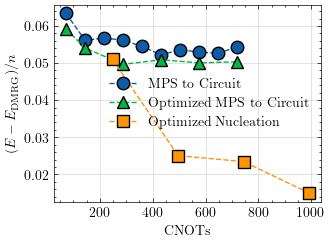

In [ ]:
from datetime import datetime


time_key = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
for points, label, marker in [
    (mps_to_circuit_points, "MPS to Circuit", "o"),
    (mps_optimized_points, "Optimized MPS to Circuit", "^"),
    (optimized_points, "Optimized Nucleation", "s"),
]:
    points = sorted(points)
    plt.plot([p[0] for p in points], [abs(p[1]) for p in points], f"--{marker}", mec="black", ms=9, label=label)

plt.xlabel("CNOTs")
plt.ylabel(r"$(E - E_{\mathrm{DMRG}}) / n$")
plt.legend()
plt.grid(alpha=0.5);
plt.tight_layout()
plt.savefig(f"nucleate_tfim_xdim_{xdim}_ydim_{ydim}_max_bond_{max_bond}_gamma_{gamma}_{time_key}.pdf")

## Save data

In [29]:
skey = f"nucleate_tfim_xdim_{xdim}_ydim_{ydim}_max_bond_{max_bond}_gamma_{gamma}_{time_key}"
np.savetxt(skey + "_mps_to_circuit.txt", mps_to_circuit_points)
np.savetxt(skey + "_optimized_mps_to_circuit.txt", mps_optimized_points)
np.savetxt(skey + "_optimized_nucleation.txt", optimized_points)